## Inputs

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns


In [ ]:
# Load the data 
df = pd.read_csv('data/recruitmentdataset-2022.csv')
df.head()

,Id,gender,age,nationality,sport,ind-university_grade,ind-debateclub,ind-programming_exp,ind-international_exp,ind-entrepeneur_exp,ind-languages,ind-exact_study,ind-degree,company,decision
0,x8011e,female,24,German,Swimming,70,False,False,False,False,1,True,phd,A,True
1,x6077a,male,26,German,Golf,67,False,True,False,False,2,True,bachelor,A,False
2,x6006e,female,23,Dutch,Running,67,False,True,True,False,0,True,master,A,False
3,x2173b,male,24,Dutch,Cricket,70,False,True,False,False,1,True,master,A,True
4,x6241a,female,26,German,Golf,59,False,False,False,False,1,False,master,A,True


## Explanatory Analysis

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4000 entries, 0 to 3999
Data columns (total 15 columns):
 #   Column                 Non-Null Count  Dtype 
---  ------                 --------------  ----- 
 0   Id                     4000 non-null   object
 1   gender                 4000 non-null   object
 2   age                    4000 non-null   int64 
 3   nationality            4000 non-null   object
 4   sport                  4000 non-null   object
 5   ind-university_grade   4000 non-null   int64 
 6   ind-debateclub         4000 non-null   bool  
 7   ind-programming_exp    4000 non-null   bool  
 8   ind-international_exp  4000 non-null   bool  
 9   ind-entrepeneur_exp    4000 non-null   bool  
 10  ind-languages          4000 non-null   int64 
 11  ind-exact_study        4000 non-null   bool  
 12  ind-degree             4000 non-null   object
 13  company                4000 non-null   object
 14  decision               4000 non-null   bool  
dtypes: bool(6), int64(3),

In [ ]:
df['gender'].value_counts()

gender
male      2127
female    1790
other       83
Name: count, dtype: int64

In [ ]:
df['ind-languages'].value_counts() # number of additional languages known by the candidates

ind-languages
1    1639
2    1349
0     676
3     336
Name: count, dtype: int64

<Axes: xlabel='company'>

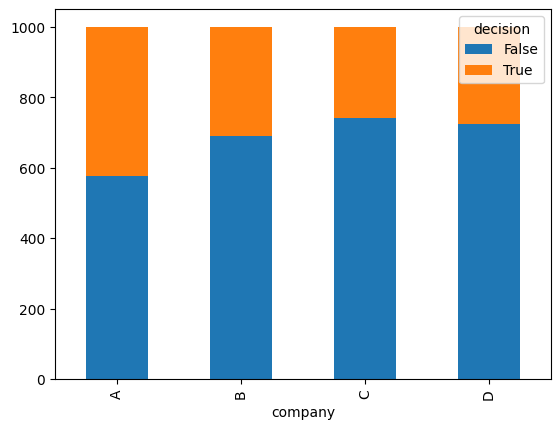

In [ ]:
df.groupby(['company','decision']).size().unstack().plot(kind='bar', stacked=True)

<Axes: xlabel='gender'>

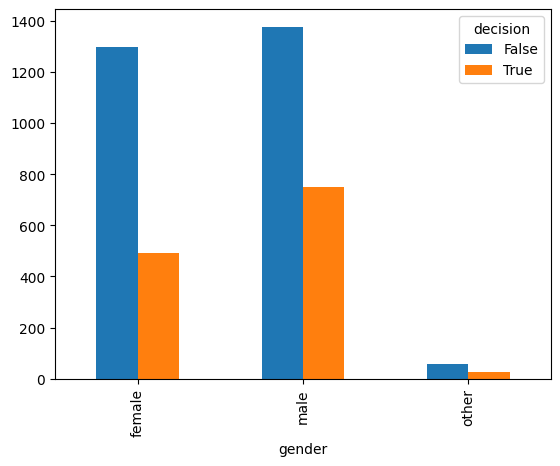

In [ ]:
df.groupby(['gender', 'decision']).size().unstack().plot(kind='bar', stacked=False)

In [ ]:
df['sport'].unique()

array(['Swimming', 'Golf', 'Running', 'Cricket', 'Chess', 'Tennis',
       'Football', 'Rugby'], dtype=object)

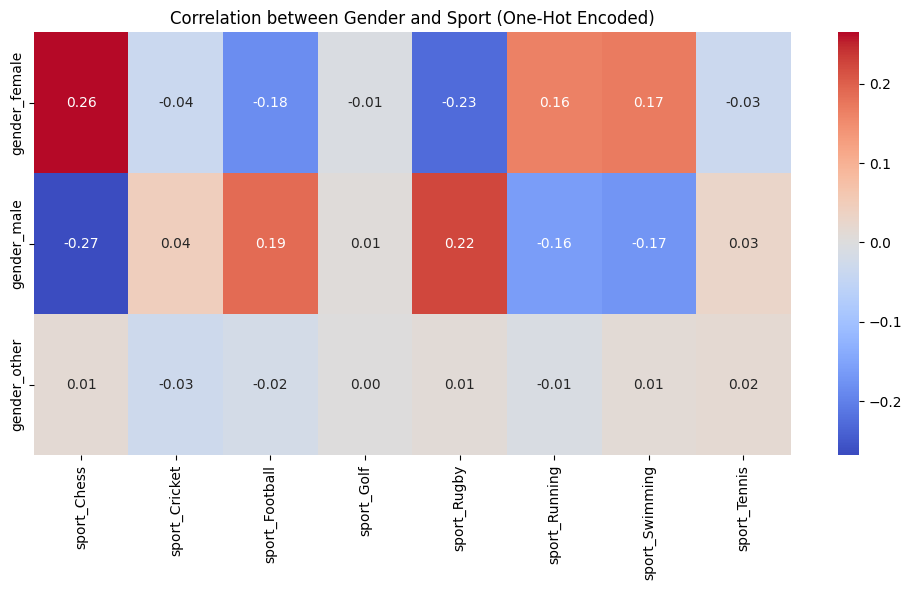

In [ ]:
# One-hot encode both columns
df_encoded = pd.get_dummies(df[['gender', 'sport']])

# Compute correlation matrix
correlation_matrix = df_encoded.corr()

# Optional: filter only gender vs sport correlations
gender_cols = [col for col in df_encoded.columns if col.startswith('gender_')]
sport_cols = [col for col in df_encoded.columns if col.startswith('sport_')]

correlation_gender_sport = correlation_matrix.loc[gender_cols, sport_cols]

# Plot heatmap
plt.figure(figsize=(10, 6))
sns.heatmap(
    correlation_gender_sport,
    annot=True,        # show values
    cmap='coolwarm',   # color palette
    center=0,
    fmt=".2f"
)

plt.title("Correlation between Gender and Sport (One-Hot Encoded)")
plt.tight_layout()
plt.show()

<Axes: >

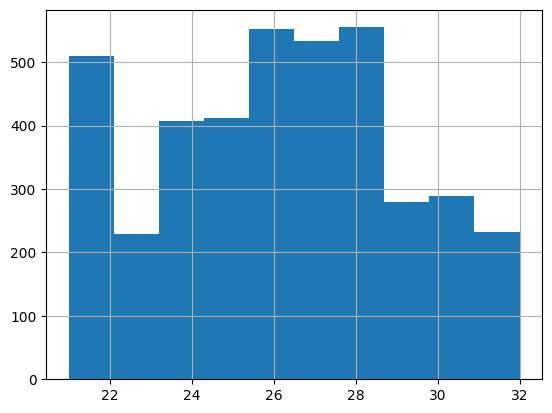

In [ ]:
df['age'].hist()